In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pylab import rc, plot
%matplotlib inline
import seaborn as sns
import itertools
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import linear_model
from sklearn import ensemble
from sklearn import metrics

In [3]:
df = pd.read_csv('telecom_churn.csv')

In [4]:
df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [5]:
d = {'Yes' : 1, 'No' : 0}

df['International plan'] = df['International plan'].map(d)
df['Voice mail plan'] = df['Voice mail plan'].map(d)

In [6]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [7]:
df.shape

(3333, 20)

In [9]:
df['Churn'] = df['Churn'].astype('int8')

In [8]:
# dict(enumerate(np.unique(df['State'])))

In [10]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
df['State'] = le.fit_transform(df['State'])


In [11]:
# Сделаем маппинг бинарных колонок
# и закодируем dummy-кодированием штат (для простоты, лучше не делать так для деревянных моделей)
ohe = preprocessing.OneHotEncoder(sparse=False)

encoded_state = ohe.fit_transform(df[['State']])

columns = ['state ' + str(i) for i in range(encoded_state.shape[1])]

tmp = pd.DataFrame(encoded_state,  columns=columns)
df = pd.concat([df, tmp], axis=1)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [12]:
df.head(5)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,state 41,state 42,state 43,state 44,state 45,state 46,state 47,state 48,state 49,state 50
0,16,128,415,0,1,25,265.1,110,45.07,197.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,35,107,415,0,1,26,161.6,123,27.47,195.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,31,137,415,0,0,0,243.4,114,41.38,121.2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,35,84,408,1,0,0,299.4,71,50.90,61.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,36,75,415,1,0,0,166.7,113,28.34,148.3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
X = df.drop(['Churn', 'State', 'Area code'], axis=1)
y = df['Churn']

In [14]:
df['Churn'].value_counts(normalize=True)

Churn
0    0.855086
1    0.144914
Name: proportion, dtype: float64

<ipython-input-15-69d95665c3a2>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( x=df['Churn'])


<Axes: ylabel='Density'>

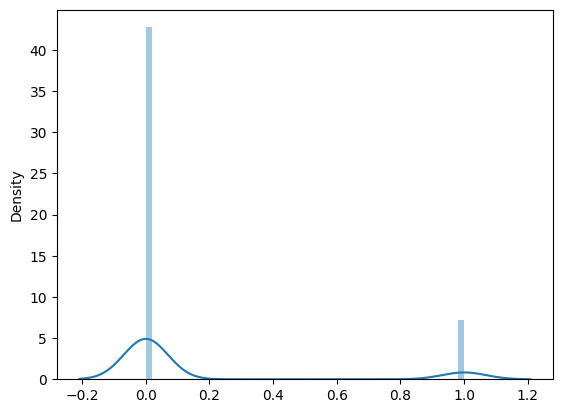

In [15]:
sns.distplot( x=df['Churn'])

In [16]:
# Делим выборку на train и test, все метрики будем оценивать на тестовом датасете
from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y,
    stratify=y,
    test_size=0.33,
    random_state=42
)

<ipython-input-17-035cfa6759b6>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( x=y_train)
<ipython-input-17-035cfa6759b6>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( x=y_test)


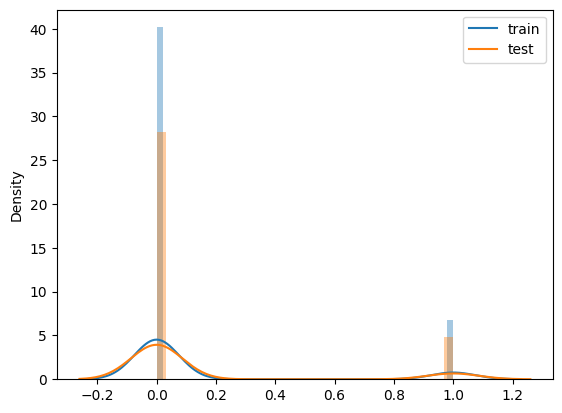

In [17]:
sns.distplot( x=y_train)
sns.distplot( x=y_test)
plt.legend(['train', 'test'])

In [18]:
# Обучаем ставшую родной логистическую регрессию
from sklearn import linear_model

lr = linear_model.LogisticRegression(random_state=42)
lr.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

Confusion matrix, without normalization
[[905  36]
 [121  38]]


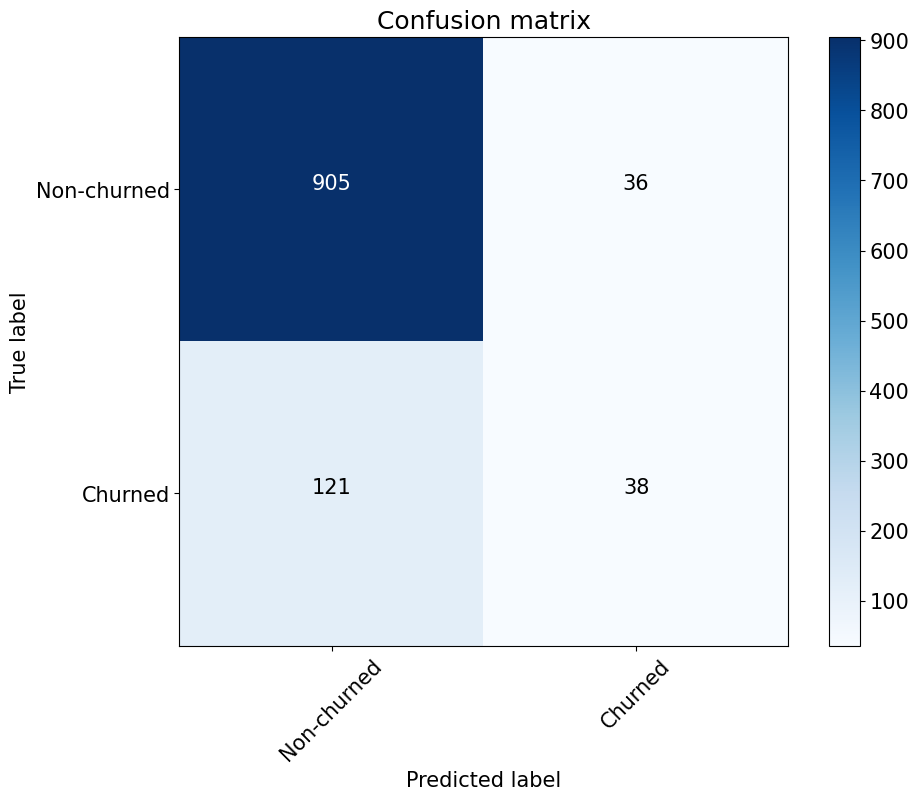

In [33]:
# Воспользуемся функцией построения матрицы ошибок из документации sklearn

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

font = {'size' : 15}

plt.rc('font', **font)

cnf_matrix = metrics.confusion_matrix(y_test, list(map(int, lr.predict_proba(X_test)[:, 1] > 0.5)))
plt.figure(figsize=(10, 8))
plot_confusion_matrix(cnf_matrix, classes=['Non-churned', 'Churned'],
                      title='Confusion matrix')
# plt.savefig("conf_matrix.png")
plt.show()

True Negative (TN) = 927  

False Positive (FP) = 13

False Negative (FN) = 152

True Positive (TP) = 8  


`accuracy = (TP + TN) / (TN + FP + TP + FN)` (в нашем случае `accuracy = 0.85`)

**Пример**

Допустим, мы хотим оценить работу спам-фильтра почты. У нас есть 100 не-спам писем, 90 из которых наш классификатор определил верно (True Negative = 90, False Positive = 10), и 10 спам-писем, 5 из которых классификатор также определил верно (True Positive = 5, False Negative = 5).
Тогда accuracy:  
`(5 + 90) / (90 + 10 + 5 + 5) = 0.864`

Однако если мы просто будем предсказывать все письма как не-спам, то получим более высокую accuracy:  
`(0 + 100) / (100 + 10 + 0 + 0) = 0.909`

При этом, наша модель совершенно не обладает никакой предсказательной силой, так как изначально мы хотели определять письма со спамом. Преодолеть это нам поможет переход с общей для всех классов метрики к отдельным показателям качества классов.

**Отток**

В нашем случае, если мы будем просто говорить, что все клиенты не уйдут, то получим такое accuracy:  
`accuracy = (0 + 941) / (941 + 159 + 0 + 0) = 0.855`

И даже в этом случае мы получаем точность чуть меньшую, чем с предиктивной моделью! В чем же дело? Почему метрика так плохо работает?

**Precision** (точность)

`precision = TP / (TP + FP) = 41 / (41 + 31) = 0.57`

**Recall** (полнота)

`recall = TP / (TP + FN) = 41 / (41 + 119) = 0.25`

![image.png](attachment:image.png)
<img src="https://habrastorage.org/web/38e/9d4/892/38e9d4892d9241ea95e1f56e3ef9124c.png", width=250, height=300>

**F b-мера**

$$F(b) = 2 * \frac{precision * recall}{b*(precision + recall)}$$

In [22]:
print("F =", 2 * 0.9 * 0.9 / (0.9 + 0.9)) # b == 1
print("F =", 2 * 0.1 * 0.9 / (0.9 + 0.1)) # b == 1

F = 0.9
F = 0.18000000000000002


In [34]:
lr.predict_proba(X_test)

array([[0.98075345, 0.01924655],
       [0.34881539, 0.65118461],
       [0.55961286, 0.44038714],
       ...,
       [0.84924091, 0.15075909],
       [0.96005565, 0.03994435],
       [0.97596039, 0.02403961]])

In [35]:
lr.predict_proba(X_test)[:, 1]

array([0.01924655, 0.65118461, 0.44038714, ..., 0.15075909, 0.03994435,
       0.02403961])

In [36]:
lr.predict_proba(X_test).argmax(axis=1)

array([0, 1, 0, ..., 0, 0, 0])

In [26]:
lr.predict(X_test)

array([0, 1, 0, ..., 0, 0, 0], dtype=int8)

In [37]:
(lr.predict_proba(X_test)[:, 1] > 0.3)

array([False,  True,  True, ..., False, False, False])

In [38]:
(lr.predict_proba(X_test)[:, 1] > 0.3).astype(int)

array([0, 1, 1, ..., 0, 0, 0])

In [39]:
def get_precision_recall(t):
    recall_pred = []
    predicts = (lr.predict_proba(X_test)[:, 1] > t).astype(int)
    for i, y in enumerate(y_test.values):
        if y == 1:
            recall_pred.append(predicts[i])
    recall = sum(recall_pred) / len(recall_pred)
    prec_pred = []
    for i, p in enumerate(predicts):
        if p == 1:
            prec_pred.append(y_test.values[i])
    precision = sum(prec_pred) / len(prec_pred)
    return precision, recall

In [40]:
get_precision_recall(0.3)

(0.41208791208791207, 0.4716981132075472)

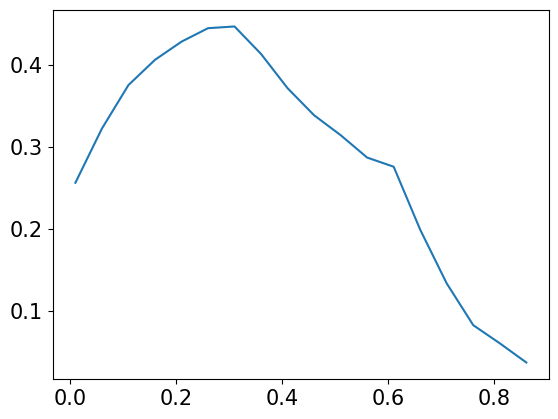

In [41]:
f_meas = []
prec_list = []
rec_list = []
for t in np.arange(0.01, 0.9, 0.05):
    prec, rec = get_precision_recall(t)
    prec_list.append(prec)
    rec_list.append(rec)
    f_m = 2 * prec * rec / (prec + rec)
    f_meas.append(f_m)

plt.plot(np.arange(0.01, 0.9, 0.05), f_meas);

In [ ]:
# 1-f1—>0

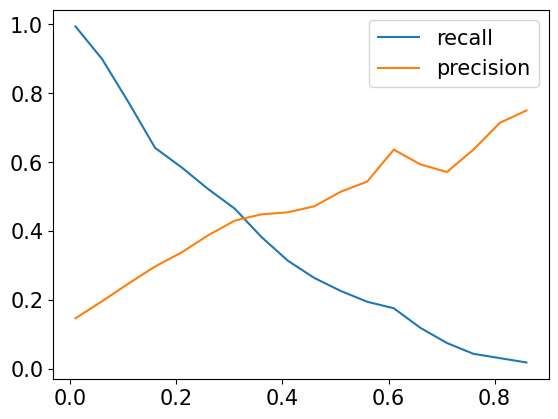

In [42]:
plt.plot(np.arange(0.01, 0.9, 0.05), rec_list)
plt.plot(np.arange(0.01, 0.9, 0.05), prec_list)
plt.legend(['recall', 'precision'])

In [43]:
prec, rec

(0.75, 0.018867924528301886)

In [44]:
np.argmax(f_meas)/100, np.max(f_meas)

(0.06, 0.4471299093655589)

In [52]:
report = metrics.classification_report(
    y_test,
    (lr.predict_proba(X_test)[:, 1] > 0.28).astype(int),
    target_names=['Non-churned', 'Churned']
)
print(report)

              precision    recall  f1-score   support

 Non-churned       0.91      0.87      0.89       941
     Churned       0.40      0.50      0.44       159

    accuracy                           0.82      1100
   macro avg       0.66      0.69      0.67      1100
weighted avg       0.84      0.82      0.83      1100



## ROC-AUC

При конвертации вещественного ответа алгоритма (как правило, вероятности принадлежности к классу, отдельно см. SVM) в бинарную метку, мы должны выбрать какой-либо порог, при котором 0 становится 1. Естественным и близким кажется порог, равный 0.5, но он не всегда оказывается оптимальным, например, при вышеупомянутом отсутствии баланса классов.


Одним из способов оценить модель в целом, не привязываясь к конкретному порогу, является AUC-ROC (или ROC AUC) — площадь (Area Under Curve) под кривой ошибок (Receiver Operating Characteristic curve ). Данная кривая представляет из себя линию от (0,0) до (1,1) в координатах True Positive Rate (TPR) и False Positive Rate (FPR):

$$TPR = \frac{TP}{TP + FN} (полнота)$$

$$FPR = \frac{FP}{FP + TN} (грязность)$$

**FPR показывает**, какую долю из объектов negative класса (в нашем случае это лояльные пользователи) алгоритм предсказал неверно

В идеальном случае, когда классификатор не делает ошибок (FPR = 0, TPR = 1) мы получим площадь под кривой, равную единице; в противном случае, когда классификатор случайно выдает вероятности классов, AUC-ROC будет стремиться к 0.5, так как классификатор будет выдавать одинаковое количество TP и FP.
Каждая точка на графике соответствует выбору некоторого порога. Площадь под кривой в данном случае показывает качество алгоритма (больше — лучше), кроме этого, важной является крутизна самой кривой — мы хотим максимизировать TPR, минимизируя FPR, а значит, наша кривая в идеале должна стремиться к точке (0,1).

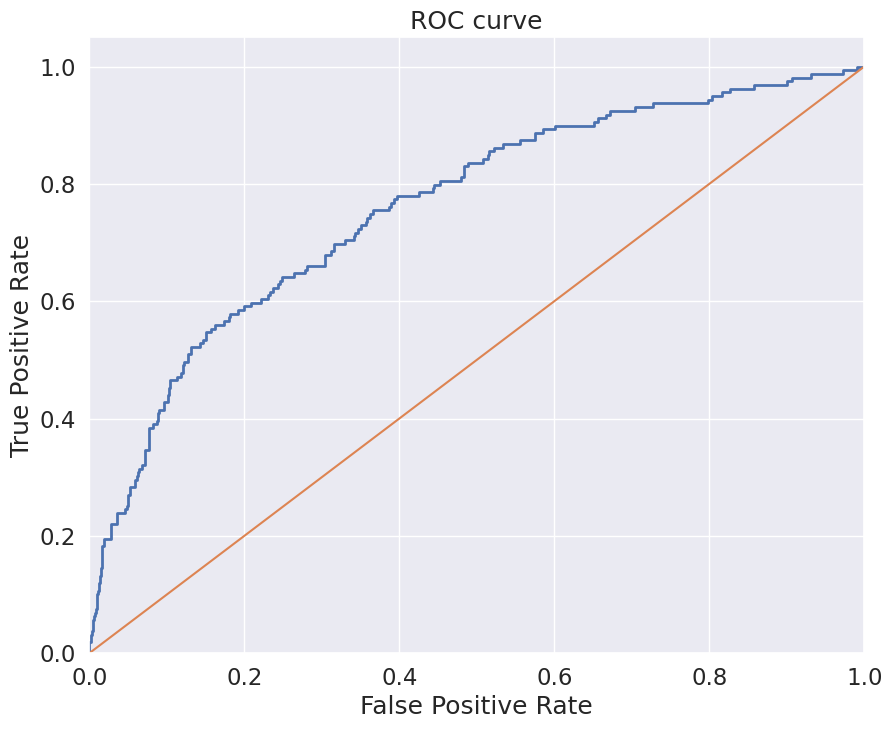

In [48]:
sns.set(font_scale=1.5)
sns.set_color_codes("muted")

plt.figure(figsize=(10, 8))
fpr, tpr, thresholds = metrics.roc_curve(y_test, lr.predict_proba(X_test)[:,1], pos_label=1)
lw = 2
plt.plot(fpr, tpr, lw=lw, label='ROC curve ')
plt.plot([0, 1], [0, 1])
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.savefig("ROC.png")
plt.show()

In [49]:
metrics.roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])

0.7607790454420895

In [ ]:
# np.c_[fpr, tpr, thresholds]

In [ ]:
auc < 0.6 - мусорная модель
0.6 < auc < 0.75 - слабая модель
0.75 < auc < 0.85 - хорошая модель
auc > 0.85 - отличная модель

In [ ]:
t = 0.75

real = [1 1 1 1 0 0 0 0]
pred = [1 0 1 1 0 1 1 0]
tpr = 0.75
fpr = 0.5

SyntaxError: invalid syntax (<ipython-input-79-2b930a67391e>, line 3)

In [ ]:
t = 0

In [50]:
print("roc-auc =", round(metrics.roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),3))

roc-auc = 0.761


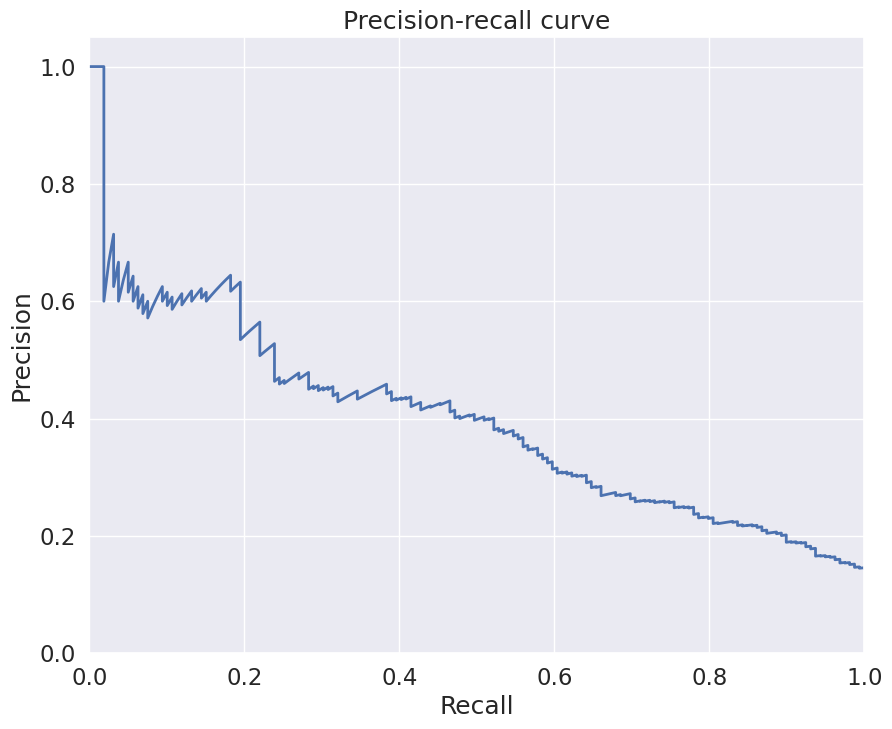

In [51]:
sns.set(font_scale=1.5)
sns.set_color_codes("muted")

plt.figure(figsize=(10, 8))
precision, recall, thresholds = metrics.precision_recall_curve(y_test, lr.predict_proba(X_test)[:,1], pos_label=1)
lw = 2
plt.plot(recall, precision, lw=lw, label='precision-recall curve')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-recall curve')
# plt.savefig("ROC.png")
plt.show()

## Log-Loss

$$\large logloss = - \frac{1}{l} \cdot \sum_{i=1}^l (y_i \cdot log(\hat y_i) + (1 - y_i) \cdot log(1 - \hat y_i))$$

здесь $\hat y_i$ — это ответ алгоритма на $i$-ом объекте, $y$ — истинная метка класса на $i$-ом объекте, а $l$ размер выборки.

Данная метрика нечасто выступает в бизнес-требованиях, но часто — в задачах на kaggle.

In [ ]:
np.log(0)

/Users/ivansnegirev/opt/anaconda3/envs/bioteh/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log
  """Entry point for launching an IPython kernel.


-inf

In [53]:
def logloss_crutch(y_true, y_pred, eps=1e-15):
    return - (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

print('Logloss при неуверенной классификации {0}'.format(
    logloss_crutch(1, 0.5)
))

print('Logloss при уверенной классификации и верном ответе {0}'.format(
    logloss_crutch(1, 0.99)
))

print('Logloss при уверенной классификации и НЕверном ответе {0}'.format(
    logloss_crutch(1, 1e-150)
))

Logloss при неуверенной классификации 0.6931471805599453
Logloss при уверенной классификации и верном ответе 0.01005033585350145
Logloss при уверенной классификации и НЕверном ответе 345.38776394910684


<img src="https://habrastorage.org/web/0fb/e4e/da3/0fbe4eda3cb3469c8d02c837b53e564e.png", width=600, height=300>![image.png](attachment:image.png)

Подытожим:

* В случае многоклассовой классификации нужно внимательно следить за метриками каждого из классов и следовать логике решения задачи, а не оптимизации метрики
* В случае неравных классов нужно подбирать баланс классов для обучения и метрику, которая будет корректно отражать качество классификации
* Выбор метрики нужно делать с фокусом на предметную область, предварительно обрабатывая данные и, возможно, сегментируя (как в случае с делением на богатых и бедных клиентов)

## Коэффициент Gini

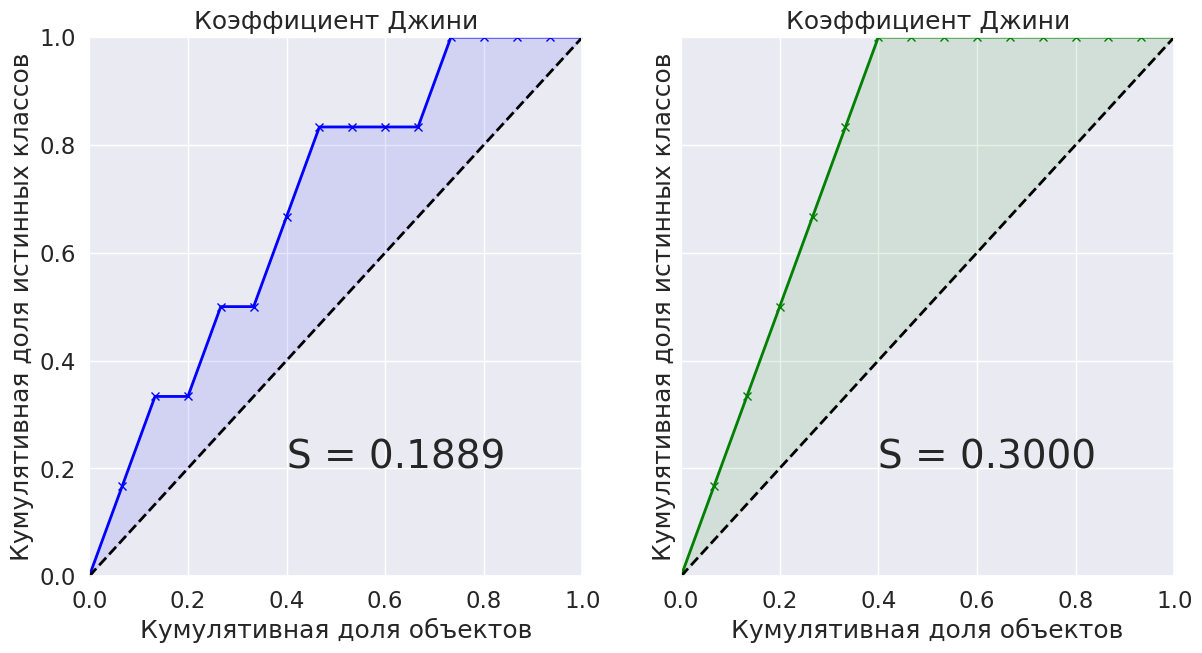

In [55]:
from scipy.interpolate import interp1d
from scipy.integrate import quad

actual = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
predict = [0.9, 0.3, 0.8, 0.75, 0.65, 0.6, 0.78, 0.7, 0.05, 0.4, 0.4, 0.05, 0.5, 0.1, 0.1]

data = zip(actual, predict)
sorted_data = sorted(data, key=lambda d: d[1], reverse=True)
sorted_actual = [d[0] for d in sorted_data]

cumulative_actual = np.cumsum(sorted_actual) / sum(actual)
cumulative_index = np.arange(1, len(cumulative_actual)+1) / len(predict)
cumulative_actual_perfect = np.cumsum(sorted(actual, reverse=True)) / sum(actual)

x_values = [0] + list(cumulative_index)
y_values = [0] + list(cumulative_actual)
y_values_perfect = [0] + list(cumulative_actual_perfect)

f1, f2 = interp1d(x_values, y_values), interp1d(x_values, y_values_perfect)
S_pred = quad(f1, 0, 1, points=x_values)[0] - 0.5
S_actual = quad(f2, 0, 1, points=x_values)[0] - 0.5

fig, ax = plt.subplots(nrows=1,ncols=2, sharey=True, figsize=(14, 7))
ax[0].plot(x_values, y_values, lw = 2, color = 'blue', marker='x')
ax[0].fill_between(x_values, x_values, y_values, color = 'blue', alpha=0.1)
ax[0].text(0.4,0.2,'S = {:0.4f}'.format(S_pred),fontsize = 28)
ax[1].plot(x_values, y_values_perfect, lw = 2, color = 'green', marker='x')
ax[1].fill_between(x_values, x_values, y_values_perfect, color = 'green', alpha=0.1)
ax[1].text(0.4,0.2,'S = {:0.4f}'.format(S_actual),fontsize = 28)

for i in range(2):
    ax[i].plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')
    ax[i].set(title='Коэффициент Джини', xlabel='Кумулятивная доля объектов',
              ylabel='Кумулятивная доля истинных классов', xlim=(0, 1), ylim=(0, 1))
plt.show();

**Зависимость с AUCROC:**

$$Gini_{normalized} = 2 * AUCROC - 1 \hspace{15pt}$$

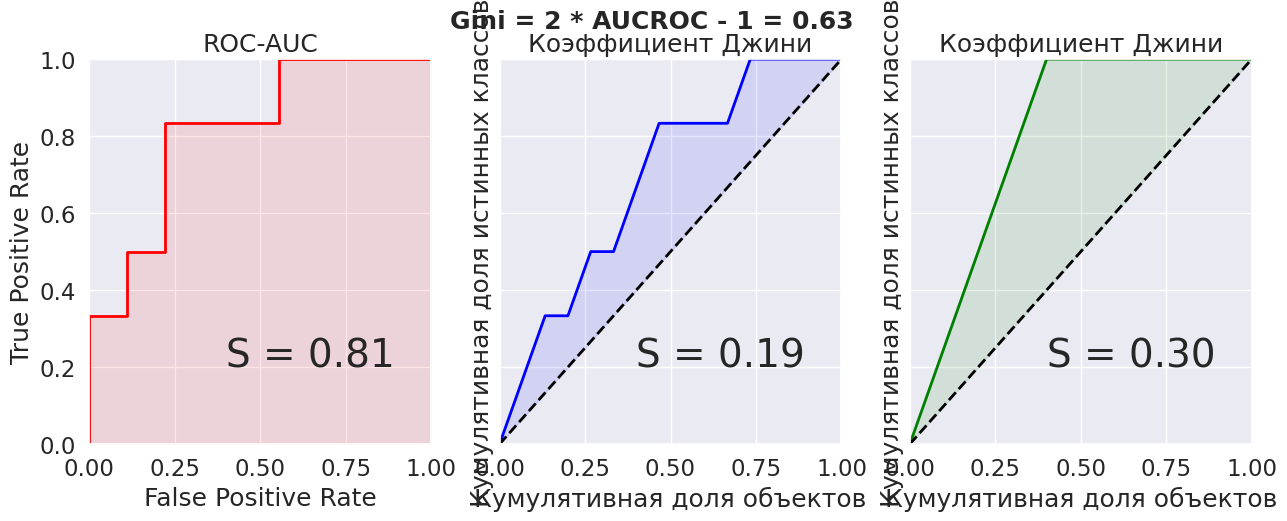

In [56]:
from sklearn.metrics import roc_curve, roc_auc_score

aucroc = roc_auc_score(actual, predict)
gini = 2*roc_auc_score(actual, predict)-1
fpr, tpr, t = roc_curve(actual, predict)


fig, ax = plt.subplots(nrows=1,ncols=3, sharey=True, figsize=(15, 5))
fig.suptitle('Gini = 2 * AUCROC - 1 = {:0.2f}\n\n'.format(gini),fontsize = 18, fontweight='bold')
ax[0].plot([0]+fpr.tolist(), [0]+tpr.tolist(), lw = 2, color = 'red')
ax[0].fill_between([0]+fpr.tolist(), [0]+tpr.tolist(), color = 'red', alpha=0.1)
ax[0].text(0.4,0.2,'S = {:0.2f}'.format(aucroc),fontsize = 28)
ax[1].plot(x_values, y_values, lw = 2, color = 'blue')
ax[1].fill_between(x_values, x_values, y_values, color = 'blue', alpha=0.1)
ax[1].text(0.4,0.2,'S = {:0.2f}'.format(S_pred),fontsize = 28)
ax[2].plot(x_values, y_values_perfect, lw = 2, color = 'green')
ax[2].fill_between(x_values, x_values, y_values_perfect, color = 'green', alpha=0.1)
ax[2].text(0.4,0.2,'S = {:0.2f}'.format(S_actual),fontsize = 28)

ax[0].set(title='ROC-AUC', xlabel='False Positive Rate',
              ylabel='True Positive Rate', xlim=(0, 1), ylim=(0, 1))
for i in range(1,3):
    ax[i].plot([0,1],[0,1],linestyle = '--',lw = 2,color = 'black')
    ax[i].set(title='Коэффициент Джини', xlabel='Кумулятивная доля объектов',
              ylabel='Кумулятивная доля истинных классов', xlim=(0, 1), ylim=(0, 1))
plt.show();

Полезная ссылка: https://habr.com/ru/company/ods/blog/350440/

## Продвинутые регрессионные метрики

Мы уже знаем про MAE и MSE

**MSLE**

Похожа на MSE, но пенализирует за ошибки в меньшую сторону сильнее, чем за ошибки в большую сторону. Такое бывает нужно для прикладных задач, когда допускается насколько-то ошибиться в одну сторону, но крайне нежелательно ошибиться в другую (постановка диагнозов - лучше перепроверить, чем пропустить; прогноз потребления продуктов в супермаркете - лучше профицит, чем дефицит)

$$\text{MSLE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (\log_e (1 + y_i) - \log_e (1 + \hat{y}_i) )^2.$$

In [ ]:
y_true = [3, 5, 2.5, 7]
y_pred = [2.5, 5, 4, 8]
print("MSE =", round(metrics.mean_squared_error(y_true, y_pred), 3))
print("MSLE =", round(metrics.mean_squared_log_error(y_true, y_pred), 3))

y_true = [3, 5, 2.5, 7]
y_pred = [2.5, 5, 1, 6]
print("MSE =", round(metrics.mean_squared_error(y_true, y_pred), 3))
print("MSLE =", round(metrics.mean_squared_log_error(y_true, y_pred), 3))

MSE = 0.875
MSLE = 0.04
MSE = 0.875
MSLE = 0.087


In [ ]:
print(np.log(1 + 0.5), np.log(1 + 0.7), np.log(1 + 0.3))
print("overestimation:", np.log(1 + 0.7) - np.log(1 + 0.5))
print("underestimation:", np.log(1 + 0.3) - np.log(1 + 0.5))

0.4054651081081644 0.5306282510621704 0.26236426446749106
overestimation: 0.125163142954006
underestimation: -0.14310084364067333


#### ДЗ.

Предложите способ как сделать так, чтобы функция сильнее пенализировала за ошибки в большую сторону, чем за ошибки в меньшую сторону

**$R^2$ - коэффициент детерминации**

$$R^2(y, \hat{y}) = 1 - \frac{\sum_{i=0}^{n_{\text{samples}} - 1} (y_i - \hat{y}_i)^2}{\sum_{i=0}^{n_\text{samples} - 1} (y_i - \bar{y})^2}$$

где $$\bar{y} =  \frac{1}{n_{\text{samples}}} \sum_{i=0}^{n_{\text{samples}} - 1} y_i$$

In [61]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

print(1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

0.9486081370449679


In [58]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([6, -5.0, 5, 6])

print(1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

-0.3447537473233404


In [59]:
np.sum((y_true - y_pred)**2) / len(y_true)

9.8125

In [60]:
np.sum((y_true - np.mean(y_true))**2) / len(y_true)

7.296875

Физический смысл - какая доля дисперсии таргета описывается регрессионной моделью.

Зависимость между коэффициентом детерминации и линейной корреляцией:

$$R^2(y, \hat{y}) = Corr(y, \hat{y})^2$$

In [ ]:
import scipy.stats as stats

In [ ]:
y_true = [3, -0.5, 2, 7]
y_pred = [1.5, 0.0, 1, 8]
print(metrics.r2_score(y_true, y_pred))
print(stats.pearsonr(y_true, y_pred)[0]**2)

0.8458244111349036
0.9013438095398676


#### Что хорошо, а что плохо?

$R^2 > 0.75$ - сильная зависимость  
$0.75 > R^2 > 0.5$ - хорошая зависимость  
$0.5 > R^2 > 0.2$ - слабая зависимость  
$0.2 < R^2$ - мусорная модель  

Регрессия:  
1. MAE
2. MSE
3. R^2
4. MSLE

Классификация:
0. Accuracy
1. Полнота (Recall)
2. Точность (Precision)
3. F-мера
4. ROC-AUC score
5. Log-loss
6. Gini

In [ ]:
metrics.SCORERS

{'explained_variance': make_scorer(explained_variance_score),
 'r2': make_scorer(r2_score),
 'max_error': make_scorer(max_error, greater_is_better=False),
 'neg_median_absolute_error': make_scorer(median_absolute_error, greater_is_better=False),
 'neg_mean_absolute_error': make_scorer(mean_absolute_error, greater_is_better=False),
 'neg_mean_absolute_percentage_error': make_scorer(mean_absolute_percentage_error, greater_is_better=False),
 'neg_mean_squared_error': make_scorer(mean_squared_error, greater_is_better=False),
 'neg_mean_squared_log_error': make_scorer(mean_squared_log_error, greater_is_better=False),
 'neg_root_mean_squared_error': make_scorer(mean_squared_error, greater_is_better=False, squared=False),
 'neg_mean_poisson_deviance': make_scorer(mean_poisson_deviance, greater_is_better=False),
 'neg_mean_gamma_deviance': make_scorer(mean_gamma_deviance, greater_is_better=False),
 'accuracy': make_scorer(accuracy_score),
 'top_k_accuracy': make_scorer(top_k_accuracy_score, ne

In [ ]:
0.1,0.2,0.3

In [ ]:
0.1,0.10001,0.101,0.2